In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
!pip install -q opencv-python matplotlib

STEP 1: Upload your image
--------------------------


Saving edge image.jpg to edge image.jpg
Image uploaded successfully!
Filename: edge image.jpg
Image size: (800, 1000, 3)


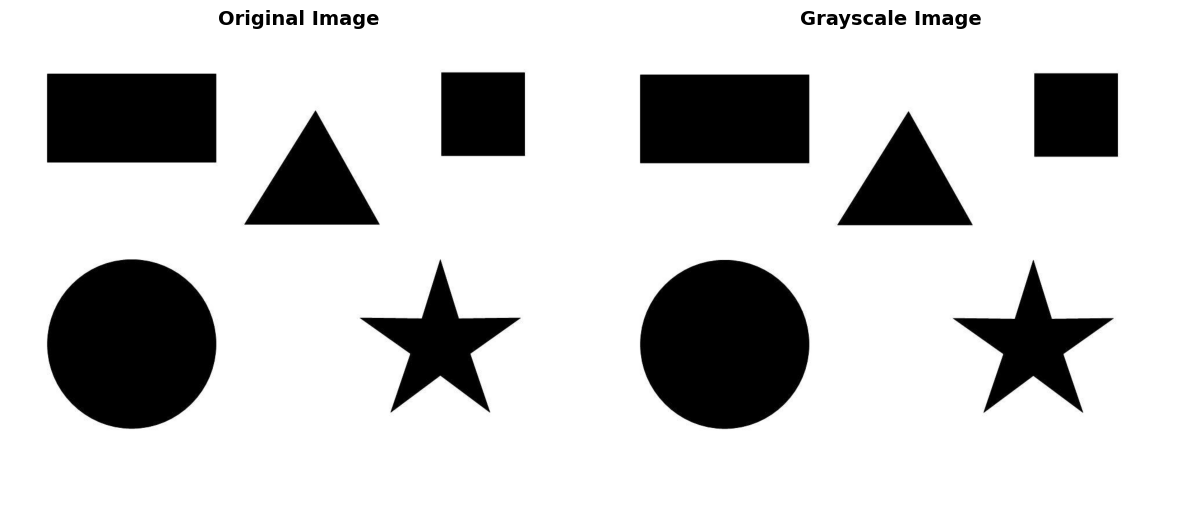


All three operators have been calculated.


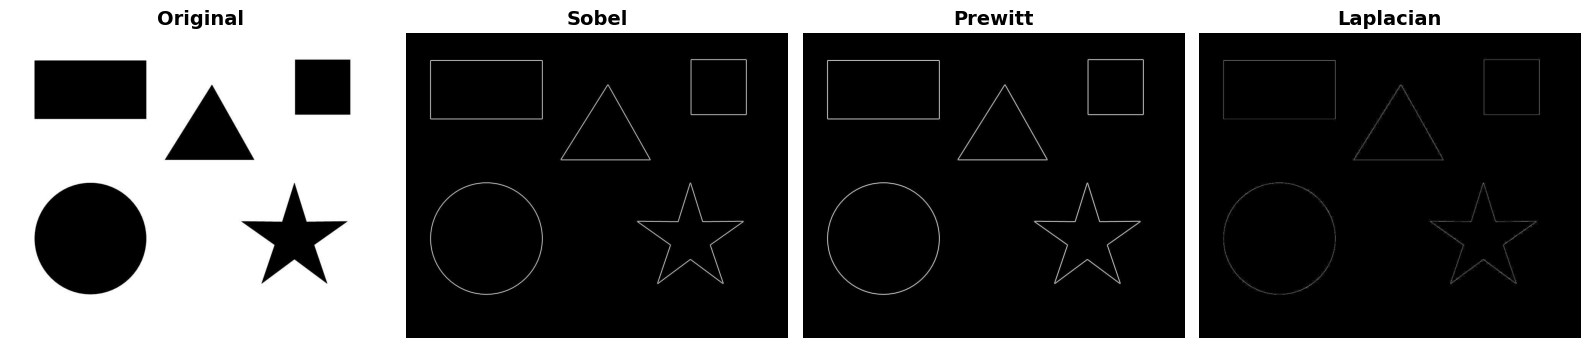


========== SOBEL KERNELS ==========

Sobel X:
[[-1  0  1]
 [-2  0  2]
 [-1  0  1]]

Sobel Y:
[[-1 -2 -1]
 [ 0  0  0]
 [ 1  2  1]]

========== PREWITT KERNELS ==========

Prewitt X:
[[-1  0  1]
 [-1  0  1]
 [-1  0  1]]

Prewitt Y:
[[-1 -1 -1]
 [ 0  0  0]
 [ 1  1  1]]

========== LAPLACIAN KERNEL ==========
[[ 0  1  0]
 [ 1 -4  1]
 [ 0  1  0]]


Select an operator:


Output()

In [ ]:
# ============================================================
# IMAGE EDGE DETECTION
# SOBEL | PREWITT | LAPLACIAN
# GOOGLE COLAB
# ============================================================



# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import display, clear_output
import ipywidgets as widgets


# ============================================================
# 1. UPLOAD IMAGE
# ============================================================

print("STEP 1: Upload your image")
print("--------------------------")

uploaded = files.upload()

if len(uploaded) == 0:
    print("No image uploaded.")
else:

    # Get filename
    filename = list(uploaded.keys())[0]

    # Read image
    image = cv2.imread(filename)

    if image is None:
        print("ERROR: Unable to read image.")

    else:

        print("Image uploaded successfully!")
        print("Filename:", filename)
        print("Image size:", image.shape)


        # ====================================================
        # 2. CONVERT IMAGE
        # ====================================================

        # BGR → RGB
        rgb_image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        # Convert to grayscale
        gray = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2GRAY
        )


        # ====================================================
        # 3. DISPLAY ORIGINAL + GRAYSCALE
        # ====================================================

        plt.figure(figsize=(12, 5))

        # Original
        plt.subplot(1, 2, 1)

        plt.imshow(rgb_image)

        plt.title(
            "Original Image",
            fontsize=14,
            fontweight="bold"
        )

        plt.axis("off")


        # Grayscale
        plt.subplot(1, 2, 2)

        plt.imshow(
            gray,
            cmap="gray"
        )

        plt.title(
            "Grayscale Image",
            fontsize=14,
            fontweight="bold"
        )

        plt.axis("off")

        plt.tight_layout()

        plt.show()


        # ====================================================
        # 4. DEFINE KERNELS
        # ====================================================

        # -------------------------
        # SOBEL KERNELS
        # -------------------------

        sobel_x_kernel = np.array([
            [-1,  0,  1],
            [-2,  0,  2],
            [-1,  0,  1]
        ])

        sobel_y_kernel = np.array([
            [-1, -2, -1],
            [ 0,  0,  0],
            [ 1,  2,  1]
        ])


        # -------------------------
        # PREWITT KERNELS
        # -------------------------

        prewitt_x_kernel = np.array([
            [-1,  0,  1],
            [-1,  0,  1],
            [-1,  0,  1]
        ])

        prewitt_y_kernel = np.array([
            [-1, -1, -1],
            [ 0,  0,  0],
            [ 1,  1,  1]
        ])


        # -------------------------
        # LAPLACIAN KERNEL
        # -------------------------

        laplacian_kernel = np.array([
            [ 0,  1,  0],
            [ 1, -4,  1],
            [ 0,  1,  0]
        ])


        # ====================================================
        # 5. OPERATOR FUNCTIONS
        # ====================================================

        def sobel_operator():

            # X direction
            gx = cv2.filter2D(
                gray,
                cv2.CV_64F,
                sobel_x_kernel
            )

            # Y direction
            gy = cv2.filter2D(
                gray,
                cv2.CV_64F,
                sobel_y_kernel
            )

            # Gradient magnitude
            magnitude = np.sqrt(
                gx**2 + gy**2
            )

            # Normalize
            result = cv2.normalize(
                magnitude,
                None,
                0,
                255,
                cv2.NORM_MINMAX
            ).astype(np.uint8)

            return result, gx, gy


        def prewitt_operator():

            # X direction
            gx = cv2.filter2D(
                gray,
                cv2.CV_64F,
                prewitt_x_kernel
            )

            # Y direction
            gy = cv2.filter2D(
                gray,
                cv2.CV_64F,
                prewitt_y_kernel
            )

            # Gradient magnitude
            magnitude = np.sqrt(
                gx**2 + gy**2
            )

            # Normalize
            result = cv2.normalize(
                magnitude,
                None,
                0,
                255,
                cv2.NORM_MINMAX
            ).astype(np.uint8)

            return result, gx, gy


        def laplacian_operator():

            # Apply Laplacian kernel
            result = cv2.filter2D(
                gray,
                cv2.CV_64F,
                laplacian_kernel
            )

            # Convert negative values
            result = np.abs(result)

            # Normalize
            result = cv2.normalize(
                result,
                None,
                0,
                255,
                cv2.NORM_MINMAX
            ).astype(np.uint8)

            return result


        # ====================================================
        # 6. CALCULATE ALL THREE OPERATORS
        # ====================================================

        sobel_result, sobel_gx, sobel_gy = sobel_operator()

        prewitt_result, prewitt_gx, prewitt_gy = prewitt_operator()

        laplacian_result = laplacian_operator()


        # ====================================================
        # 7. DISPLAY ALL RESULTS
        # ====================================================

        print("\nAll three operators have been calculated.")


        plt.figure(figsize=(16, 5))


        # Original
        plt.subplot(1, 4, 1)

        plt.imshow(
            rgb_image
        )

        plt.title(
            "Original",
            fontsize=14,
            fontweight="bold"
        )

        plt.axis("off")


        # Sobel
        plt.subplot(1, 4, 2)

        plt.imshow(
            sobel_result,
            cmap="gray"
        )

        plt.title(
            "Sobel",
            fontsize=14,
            fontweight="bold"
        )

        plt.axis("off")


        # Prewitt
        plt.subplot(1, 4, 3)

        plt.imshow(
            prewitt_result,
            cmap="gray"
        )

        plt.title(
            "Prewitt",
            fontsize=14,
            fontweight="bold"
        )

        plt.axis("off")


        # Laplacian
        plt.subplot(1, 4, 4)

        plt.imshow(
            laplacian_result,
            cmap="gray"
        )

        plt.title(
            "Laplacian",
            fontsize=14,
            fontweight="bold"
        )

        plt.axis("off")


        plt.tight_layout()

        plt.show()


        # ====================================================
        # 8. DISPLAY KERNELS
        # ====================================================

        print("\n========== SOBEL KERNELS ==========")

        print("\nSobel X:")
        print(sobel_x_kernel)

        print("\nSobel Y:")
        print(sobel_y_kernel)


        print("\n========== PREWITT KERNELS ==========")

        print("\nPrewitt X:")
        print(prewitt_x_kernel)

        print("\nPrewitt Y:")
        print(prewitt_y_kernel)


        print("\n========== LAPLACIAN KERNEL ==========")

        print(laplacian_kernel)


        # ====================================================
        # 9. INTERACTIVE BUTTONS
        # ====================================================

        print("\n")
        print("Select an operator:")


        sobel_button = widgets.Button(
            description="Sobel",
            button_style="primary",
            layout=widgets.Layout(
                width="150px",
                height="40px"
            )
        )


        prewitt_button = widgets.Button(
            description="Prewitt",
            button_style="success",
            layout=widgets.Layout(
                width="150px",
                height="40px"
            )
        )


        laplacian_button = widgets.Button(
            description="Laplacian",
            button_style="warning",
            layout=widgets.Layout(
                width="150px",
                height="40px"
            )
        )


        output = widgets.Output()


        # ====================================================
        # 10. BUTTON FUNCTIONS
        # ====================================================

        def show_sobel(button):

            with output:

                clear_output(wait=True)

                plt.figure(figsize=(15, 5))


                plt.subplot(1, 3, 1)

                plt.imshow(
                    np.abs(sobel_gx),
                    cmap="gray"
                )

                plt.title(
                    "Sobel X",
                    fontsize=14,
                    fontweight="bold"
                )

                plt.axis("off")


                plt.subplot(1, 3, 2)

                plt.imshow(
                    np.abs(sobel_gy),
                    cmap="gray"
                )

                plt.title(
                    "Sobel Y",
                    fontsize=14,
                    fontweight="bold"
                )

                plt.axis("off")


                plt.subplot(1, 3, 3)

                plt.imshow(
                    sobel_result,
                    cmap="gray"
                )

                plt.title(
                    "Sobel Final Output",
                    fontsize=14,
                    fontweight="bold"
                )

                plt.axis("off")


                plt.tight_layout()

                plt.show()


                print("Sobel Operator Applied")


        def show_prewitt(button):

            with output:

                clear_output(wait=True)

                plt.figure(figsize=(15, 5))


                plt.subplot(1, 3, 1)

                plt.imshow(
                    np.abs(prewitt_gx),
                    cmap="gray"
                )

                plt.title(
                    "Prewitt X",
                    fontsize=14,
                    fontweight="bold"
                )

                plt.axis("off")


                plt.subplot(1, 3, 2)

                plt.imshow(
                    np.abs(prewitt_gy),
                    cmap="gray"
                )

                plt.title(
                    "Prewitt Y",
                    fontsize=14,
                    fontweight="bold"
                )

                plt.axis("off")


                plt.subplot(1, 3, 3)

                plt.imshow(
                    prewitt_result,
                    cmap="gray"
                )

                plt.title(
                    "Prewitt Final Output",
                    fontsize=14,
                    fontweight="bold"
                )

                plt.axis("off")


                plt.tight_layout()

                plt.show()


                print("Prewitt Operator Applied")


        def show_laplacian(button):

            with output:

                clear_output(wait=True)

                plt.figure(figsize=(10, 6))


                plt.imshow(
                    laplacian_result,
                    cmap="gray"
                )

                plt.title(
                    "Laplacian Final Output",
                    fontsize=16,
                    fontweight="bold"
                )

                plt.axis("off")

                plt.show()


                print("Laplacian Operator Applied")


        # ====================================================
        # 11. CONNECT BUTTONS
        # ====================================================

        sobel_button.on_click(
            show_sobel
        )

        prewitt_button.on_click(
            show_prewitt
        )

        laplacian_button.on_click(
            show_laplacian
        )


        # ====================================================
        # 12. DISPLAY BUTTONS
        # ====================================================

        display(
            widgets.HBox([
                sobel_button,
                prewitt_button,
                laplacian_button
            ])
        )

        display(output)